# SplitFed Demonstration Notebook

This notebook provides a simple interactive setup of the Split Federated Learning (SplitFed) simulator.
We will load the MNIST dataset, partition it among 3 simulated clients, and run a short training loop.

### Step 0: Remote Server Setup

If you are running this notebook on a remote Jupyter server (like Google Colab), run the following cell to clone the repository, install dependencies, and set the correct working directory.

In [4]:
import os, subprocess, sys
from pathlib import Path

repo_url = "https://github.com/tomal66/ad-sfl.git"
repo_path = Path("/content/ad-sfl")  # Colab workspace

def run(cmd, cwd=None):
    return subprocess.run(cmd, cwd=cwd, check=True, text=True, capture_output=True)

# 1) Clone if missing
if not repo_path.exists():
    subprocess.run(["git", "clone", repo_url, str(repo_path)], check=True)

# 2) Sanity check: must be a git repo now
if not (repo_path / ".git").exists():
    raise RuntimeError(
        f"{repo_path} exists but is not a git repo (no .git). "
        f"Delete/rename that folder or choose a different repo_path."
    )

# 3) Update: fetch + reset to remote default branch
subprocess.run(["git", "fetch", "--all", "--prune"], cwd=repo_path, check=True)

default_ref = run(["git", "symbolic-ref", "refs/remotes/origin/HEAD"], cwd=repo_path).stdout.strip()
branch = default_ref.split("/")[-1]  # e.g., main / master

subprocess.run(["git", "checkout", branch], cwd=repo_path, check=True)
subprocess.run(["git", "reset", "--hard", f"origin/{branch}"], cwd=repo_path, check=True)
subprocess.run(["git", "clean", "-fd"], cwd=repo_path, check=True)

# 4) Set cwd to repo folder
os.chdir(repo_path)
print("CWD:", os.getcwd())
print("Branch:", branch)
print("HEAD:", run(["git", "rev-parse", "HEAD"], cwd=repo_path).stdout.strip())

# 5) Optional: install requirements if present
req = repo_path / "requirements.txt"
if req.exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(req)], check=True)

CWD: /content/ad-sfl
Branch: main
HEAD: fd2326cf52048c00f80f7a99090407ce6e68a892


In [5]:
import torch
from src.data.datasets import get_datasets
from src.data.partition import partition_data_iid, partition_data_dirichlet
from src.models.split import ClientModel, ServerModel
from src.core.client import SplitFedClient
from src.core.server import SplitFedServer
from src.core.seed import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


### Step 1: Load and Partition Data

In [ ]:
# --- HYPERPARAMETERS & REPRODUCIBILITY ---
num_clients = 10
batch_size = 64
learning_rate = 0.01

GLOBAL_SEED = 42
set_seed(GLOBAL_SEED)
DATASET = "CIFAR10"

# Non-IID Dirichlet alpha (smaller means more unbalanced)
DIRICHLET_ALPHA = 1
# -----------------------------------------
# Hugging Face Token (if required for gated datasets like ImageNet)
HF_TOKEN = ""

print(f"Loading {DATASET} dataset...")
train_data, test_data = get_datasets(dataset_name=DATASET, hf_token=HF_TOKEN)

print(f"Partitioning data info Non-IID subsets (Dirichlet alpha={DIRICHLET_ALPHA})...")
client_datasets = partition_data_dirichlet(train_data, num_clients, alpha=DIRICHLET_ALPHA)


Global seed set to: 42
Loading CIFAR10 dataset...
Partitioning data info Non-IID subsets (Dirichlet alpha=1)...


### Step 2: Initialize Server and Client Models

In SplitFed, a portion of the network is on the client, and the rest is on the server.

In [10]:
import copy

from src.models.split import get_split_models

base_client_model, server_model = get_split_models(DATASET)
server = SplitFedServer(model=server_model, num_clients=num_clients, lr=learning_rate, device=device)



clients = []
for i in range(num_clients):
    client_model = copy.deepcopy(base_client_model)
    client = SplitFedClient(client_id=i, model=client_model, dataset=client_datasets[i], batch_size=batch_size, lr=learning_rate, device=device)
    clients.append(client)

print("Initialized 1 Server and 10 Clients.")

Initialized 1 Server and 10 Clients.


In [11]:
import torch
from collections import OrderedDict

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable = total - trainable
    return {"total": total, "trainable": trainable, "non_trainable": non_trainable}

def format_counts(title, d):
    return f"{title}: total={d['total']:,} | trainable={d['trainable']:,} | non-trainable={d['non_trainable']:,}"

# --- client / server ---
client_counts = count_params(base_client_model)
server_counts = count_params(server_model)

# --- combined (client + server) ---
# safest: sum counts (no risk of name collisions)
combined_counts = {
    "total": client_counts["total"] + server_counts["total"],
    "trainable": client_counts["trainable"] + server_counts["trainable"],
    "non_trainable": client_counts["non_trainable"] + server_counts["non_trainable"],
}

print(format_counts("CLIENT", client_counts))
print(format_counts("SERVER", server_counts))
print(format_counts("COMBINED", combined_counts))

CLIENT: total=149,824 | trainable=149,824 | non-trainable=0
SERVER: total=11,024,138 | trainable=11,024,138 | non-trainable=0
COMBINED: total=11,173,962 | trainable=11,173,962 | non-trainable=0


### Step 3: Simulation Loop

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training simulation complete. Plotting accuracy...


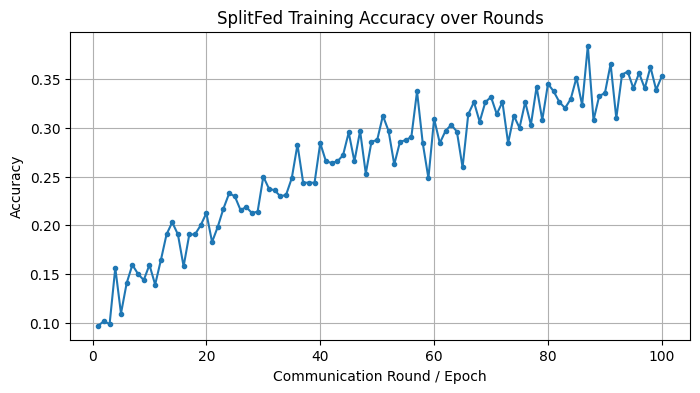

In [12]:
import matplotlib.pyplot as plt
from tqdm.auto import trange
from src.algorithms import run_sfl_round

epochs = 100
historical_acc = []

pbar = trange(epochs, desc="Training", unit="epoch")
for epoch in pbar:
    avg_loss, avg_acc = run_sfl_round(clients, server)
    historical_acc.append(avg_acc)
    pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{avg_acc:.4f}")

print("Training simulation complete. Plotting accuracy...")
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), historical_acc, marker="o", markersize=3)
plt.title("SplitFed Training Accuracy over Rounds")
plt.xlabel("Communication Round / Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()
